In [11]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gerber_cov import gerber_covariance


In [12]:
# Cell 2: Load returns
returns = pd.read_csv("sample_data.csv", index_col=0, parse_dates=True).sort_index()
returns = returns.dropna(axis=1, how="any").dropna()
returns.head()

,BAJFINANCE,EICHERMOT,ADANIENT,TRENT,TITAN,BAJAJFINSV,BRITANNIA,APOLLOHOSP,ASIANPAINT,SHREECEM,HINDPETRO,HCLTECH,SHRIRAMFIN,DIVISLAB,INDUSINDBK
Date,,,,,,,,,,,,,,,
2010-03-03,31.58,67.1,46.69,81.64,89.87,34.10,167.80,360.0,188.0,2171.38,29.45,90.80,91.60,317.50,153.95
2010-03-04,31.20,66.8,47.75,81.16,90.80,34.00,174.97,350.6,198.8,2230.41,29.65,95.50,88.40,325.65,166.00
2010-03-05,31.56,65.8,47.56,81.83,94.00,33.15,175.50,352.0,197.4,2242.93,29.75,90.05,89.85,325.00,160.05
2010-03-08,31.77,67.9,48.81,78.84,92.45,33.70,169.77,362.5,198.0,2265.74,30.10,89.40,91.00,331.85,161.40
2010-03-09,31.46,64.6,48.55,80.73,90.50,32.90,166.00,353.0,193.5,2202.34,30.10,89.15,93.55,324.40,161.00


In [13]:
raw_cov = returns.cov()
ger_cov = gerber_covariance(returns, c=0.5)

print("Raw cov shape:", raw_cov.shape)
print("Gerber cov shape:", ger_cov.shape)


Raw cov shape: (15, 15)
Gerber cov shape: (15, 15)


We compare raw vs. Gerber covariance using rolling eigenvalue stability

In [14]:
# Cell 5: 1) Eigenvalue stability (rolling)
window = 252
step = 21

def rolling_eig_stats(returns_df: pd.DataFrame, cov_fn):
    rows = []
    for end in range(window, len(returns_df) + 1, step):
        w = returns_df.iloc[end - window:end]
        cov = cov_fn(w)
        m = cov.values if isinstance(cov, pd.DataFrame) else cov
        eig = np.linalg.eigvalsh(m)
        min_eig = float(eig.min())
        max_eig = float(eig.max())
        cond_num = max_eig / max(min_eig, 1e-12)
        rows.append(
            {"date": returns_df.index[end - 1], "min_eig": min_eig, "cond_num": cond_num}
        )
    return pd.DataFrame(rows).set_index("date")

raw_eig = rolling_eig_stats(returns, lambda x: x.cov())
ger_eig = rolling_eig_stats(returns, lambda x: gerber_covariance(x, c=0.5))




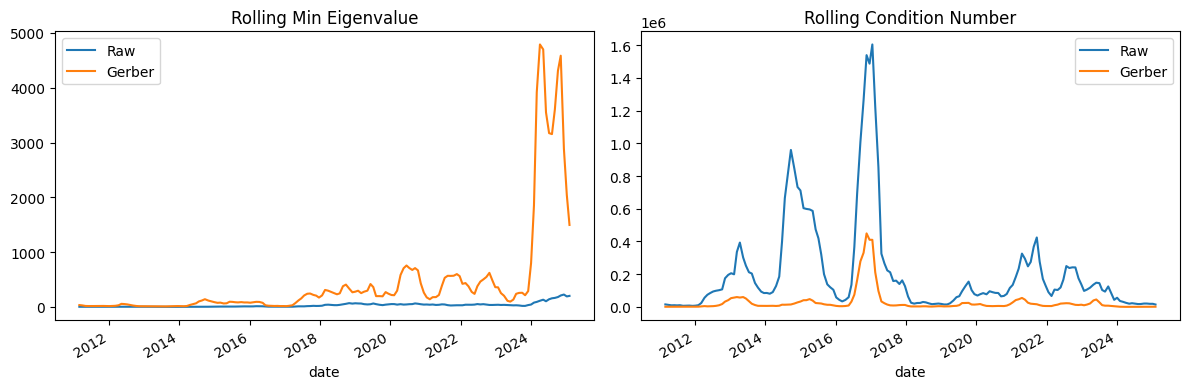

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
raw_eig["min_eig"].plot(ax=ax[0], label="Raw")
ger_eig["min_eig"].plot(ax=ax[0], label="Gerber")
ax[0].set_title("Rolling Min Eigenvalue")
ax[0].legend()

raw_eig["cond_num"].plot(ax=ax[1], label="Raw")
ger_eig["cond_num"].plot(ax=ax[1], label="Gerber")
ax[1].set_title("Rolling Condition Number")
ax[1].legend()
plt.tight_layout()